# Transaction Risk Analytics

This notebook summarizes an MVP analytics project for transaction risk monitoring.

The data is synthetic. The goal is not to build a production fraud detection system, but to demonstrate SQL, pandas, EDA, peer-group comparison, heuristic risk scoring, and business interpretation.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

BASE_DIR = Path("..")
RAW_DIR = BASE_DIR / "data" / "raw"
TABLES_DIR = BASE_DIR / "outputs" / "tables"
FIGURES_DIR = BASE_DIR / "outputs" / "figures"

In [2]:
users = pd.read_csv(RAW_DIR / "users.csv")
merchants = pd.read_csv(RAW_DIR / "merchants.csv")
transactions = pd.read_csv(RAW_DIR / "transactions.csv")
merchant_scores = pd.read_csv(TABLES_DIR / "merchant_risk_scores.csv")
user_scores = pd.read_csv(TABLES_DIR / "user_risk_scores.csv")

users.head(), merchants.head(), transactions.head()

(  user_id signup_date  age              city   segment risk_profile
 0  U00001  2025-09-16   41   Nizhny Novgorod   student          low
 1  U00002  2024-01-29   42             Kazan      mass         high
 2  U00003  2024-05-12   39            Moscow      mass         high
 3  U00004  2024-11-16   19   Nizhny Novgorod      mass       medium
 4  U00005  2024-11-21   18  Saint Petersburg  affluent          low,
   merchant_id         category   mcc         city registration_date  \
 0       M0001         pharmacy  5912       Moscow        2025-10-22   
 1       M0002  online_services  4899       Moscow        2023-03-05   
 2       M0003      electronics  5732       Moscow        2023-05-04   
 3       M0004             fuel  5541       Moscow        2024-04-09   
 4       M0005  online_services  4899  Novosibirsk        2025-11-06   
 
   merchant_size  base_amount  
 0         small         1200  
 1         large         1300  
 2         small         8000  
 3        medium       

## Data quality checks

In [3]:
quality_rows = []

for name, df in {
    "users": users,
    "merchants": merchants,
    "transactions": transactions,
    "merchant_scores": merchant_scores,
    "user_scores": user_scores,
}.items():
    quality_rows.append(
        {
            "table": name,
            "rows": len(df),
            "columns": df.shape[1],
            "duplicate_rows": int(df.duplicated().sum()),
            "missing_values_total": int(df.isna().sum().sum()),
        }
    )

pd.DataFrame(quality_rows)

,table,rows,columns,duplicate_rows,missing_values_total
0,users,800,6,0,0
1,merchants,120,7,0,0
2,transactions,20580,9,0,0
3,merchant_scores,120,25,0,0
4,user_scores,800,30,0,0


## Transaction amount distribution

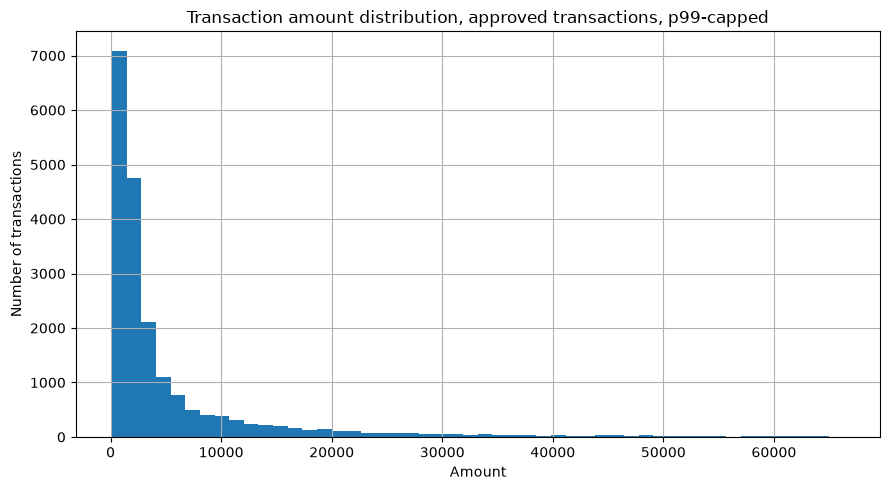

In [4]:
approved = transactions[transactions["status"] == "approved"].copy()
upper = approved["amount"].quantile(0.99)

plt.figure(figsize=(9, 5))
approved.loc[approved["amount"] <= upper, "amount"].hist(bins=50)
plt.title("Transaction amount distribution, approved transactions, p99-capped")
plt.xlabel("Amount")
plt.ylabel("Number of transactions")
plt.tight_layout()
plt.show()

## Daily turnover

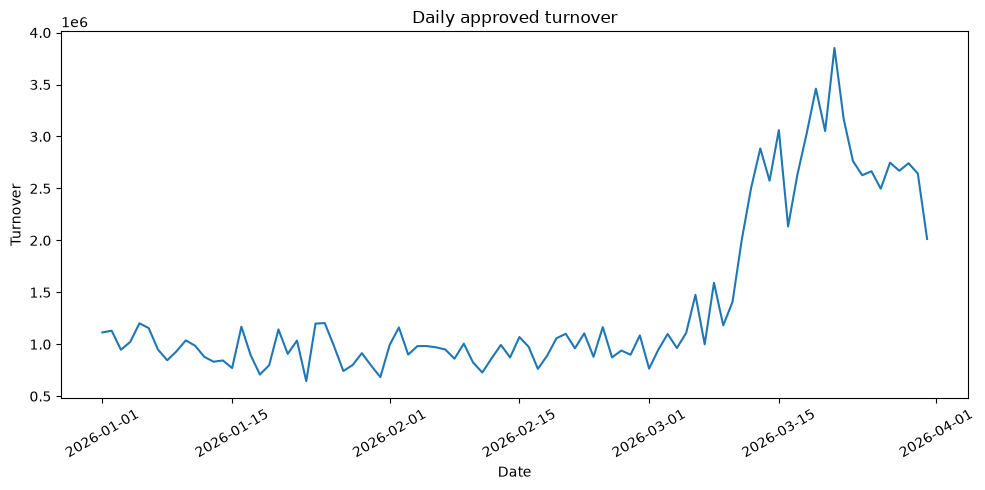

In [5]:
approved["tx_date"] = pd.to_datetime(approved["tx_timestamp"]).dt.date
daily_turnover = approved.groupby("tx_date", as_index=False)["amount"].sum()

plt.figure(figsize=(10, 5))
plt.plot(pd.to_datetime(daily_turnover["tx_date"]), daily_turnover["amount"])
plt.title("Daily approved turnover")
plt.xlabel("Date")
plt.ylabel("Turnover")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

## Top risky merchants

In [6]:
merchant_scores[
    [
        "merchant_id",
        "category",
        "city",
        "risk_score",
        "risk_level",
        "turnover_peer_ratio",
        "avg_ticket_peer_ratio",
        "night_tx_share",
        "risk_reasons",
    ]
].head(10)

,merchant_id,category,city,risk_score,risk_level,turnover_peer_ratio,avg_ticket_peer_ratio,night_tx_share,risk_reasons
0,M0058,grocery,Moscow,51.7,medium,4.1693,1.7042,0.2532,turnover is much higher than category-city peers
1,M0016,restaurants,Moscow,46.2,medium,3.7417,1.6286,0.2655,turnover is much higher than category-city peers
2,M0079,online_services,Novosibirsk,39.9,low,3.1704,1.7016,0.2440,turnover is much higher than category-city peers
3,M0080,restaurants,Nizhny Novgorod,35.1,low,2.5685,1.7569,0.3406,high share of night transactions
4,M0110,jewelry,Saint Petersburg,27.7,low,1.8164,1.3925,0.3120,high share of night transactions
5,M0068,pharmacy,Saint Petersburg,20.6,low,2.1304,1.0285,0.0973,no strong risk signal
6,M0035,grocery,Novosibirsk,20.6,low,2.0681,1.0784,0.1179,no strong risk signal
7,M0036,pharmacy,Moscow,19.7,low,2.1052,0.9704,0.0891,no strong risk signal
8,M0049,restaurants,Saint Petersburg,19.1,low,2.1292,1.0571,0.0903,no strong risk signal
9,M0002,online_services,Moscow,19.0,low,2.0126,0.9863,0.1140,no strong risk signal


## Top risky users

In [7]:
user_scores[
    [
        "user_id",
        "segment",
        "city",
        "risk_score",
        "risk_level",
        "total_amount_peer_ratio",
        "tx_count_peer_ratio",
        "max_daily_tx_count",
        "risk_reasons",
    ]
].head(10)

,user_id,segment,city,risk_score,risk_level,total_amount_peer_ratio,tx_count_peer_ratio,max_daily_tx_count,risk_reasons
0,U00534,mass,Kazan,82.4,high,5.0827,3.8382,27,total amount is much higher than segment-city ...
1,U00144,mass,Saint Petersburg,79.2,high,4.8126,4.1736,24,total amount is much higher than segment-city ...
2,U00066,mass,Moscow,79.0,high,4.1066,4.3136,27,total amount is much higher than segment-city ...
3,U00393,mass,Ekaterinburg,76.4,high,3.4133,4.0797,32,total amount is much higher than segment-city ...
4,U00210,mass,Kazan,76.2,high,4.3848,3.4377,24,total amount is much higher than segment-city ...
5,U00438,mass,Moscow,74.6,high,4.1041,4.3136,24,total amount is much higher than segment-city ...
6,U00143,affluent,Saint Petersburg,70.7,high,3.1488,4.0946,25,total amount is much higher than segment-city ...
7,U00265,affluent,Nizhny Novgorod,70.5,high,3.7460,3.8506,24,total amount is much higher than segment-city ...
8,U00755,mass,Saint Petersburg,68.0,medium,3.1876,3.9480,23,total amount is much higher than segment-city ...
9,U00351,mass,Kazan,68.0,medium,2.8195,3.3709,25,transaction count is unusually high; burst-lik...


## Business conclusion

High-risk objects are candidates for additional review, not automatically fraudulent objects.

The heuristic score highlights merchants and users whose transaction behavior is atypical relative to comparable peer groups. In a real banking setting, this analysis should be enriched with chargebacks, disputes, KYC data, device fingerprints, customer complaints, refunds, and confirmed fraud labels.